In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# This tells the notebook how to handle the plots and warnings
warnings.filterwarnings('ignore')

# Load the Ethiopia data (make sure the filename is correct)
df = pd.read_csv("data/ethiopia_clean.csv")

# Now 'plt' is defined and ready to work!

In [4]:
import os

# Check for the clean file first
if os.path.exists("data/ethiopia_clean.csv"):
    df = pd.read_csv("data/ethiopia_clean.csv")
    print("Loaded: data/ethiopia_clean.csv")
elif os.path.exists("data/ethiopia.csv"):
    df = pd.read_csv("data/ethiopia.csv")
    print("Loaded: data/ethiopia.csv")
else:
    print("ERROR: CSV file not found in the 'data' folder!")

# Show the first 5 rows to confirm it worked
df.head()

Loaded: data/ethiopia_clean.csv


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


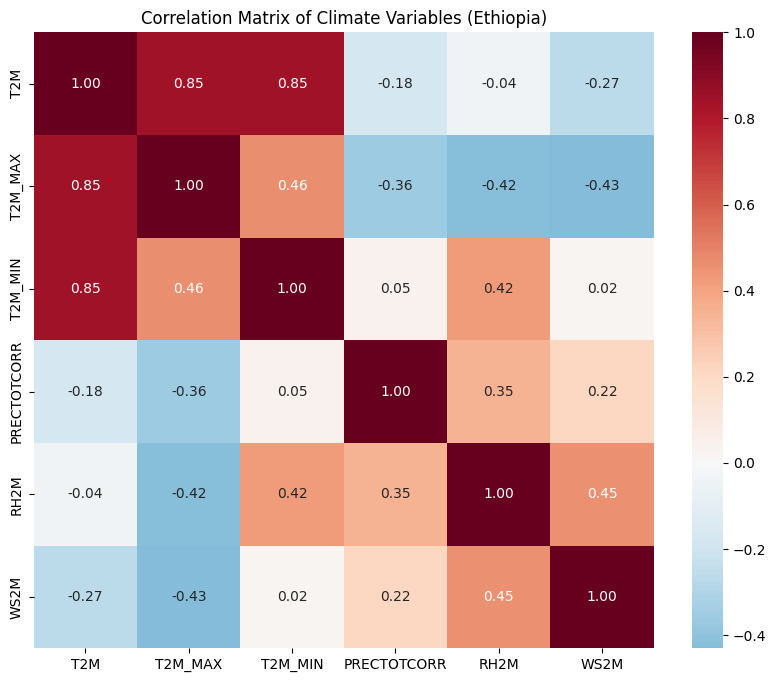

In [5]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']

# We use numeric_only=True to avoid errors with date columns
sns.heatmap(df[weather_cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlation Matrix of Climate Variables (Ethiopia)')
plt.show()

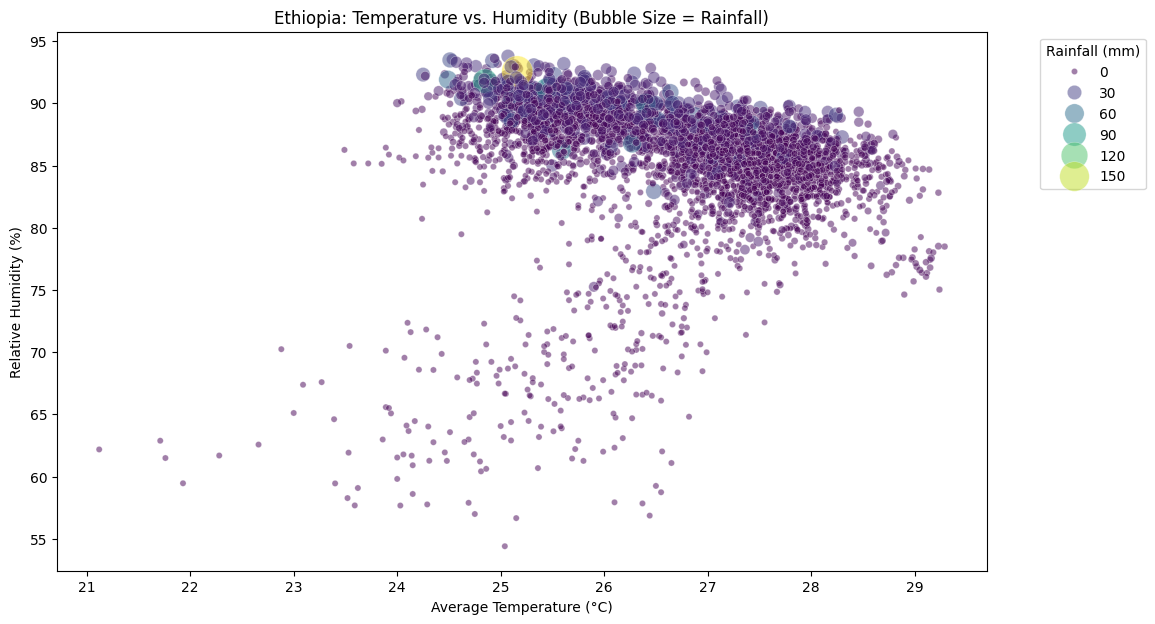

In [6]:

# Bubble Chart: Distribution Analysis
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x="T2M", 
    y="RH2M", 
    size="PRECTOTCORR", 
    hue="PRECTOTCORR", 
    sizes=(20, 500), 
    alpha=0.5, 
    palette="viridis"
)
plt.title("Ethiopia: Temperature vs. Humidity (Bubble Size = Rainfall)")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Rainfall (mm)")
plt.show()

In [20]:
# Saving it back to the expected name for the submission
df.to_csv("data/ethiopia_clean.csv", index=False)
print("Final file saved successfully!")

Final file saved successfully!


In [21]:
df.to_csv("data/ethiopia_clean.csv", index=False)
print("Ethiopia data saved!")

Ethiopia data saved!


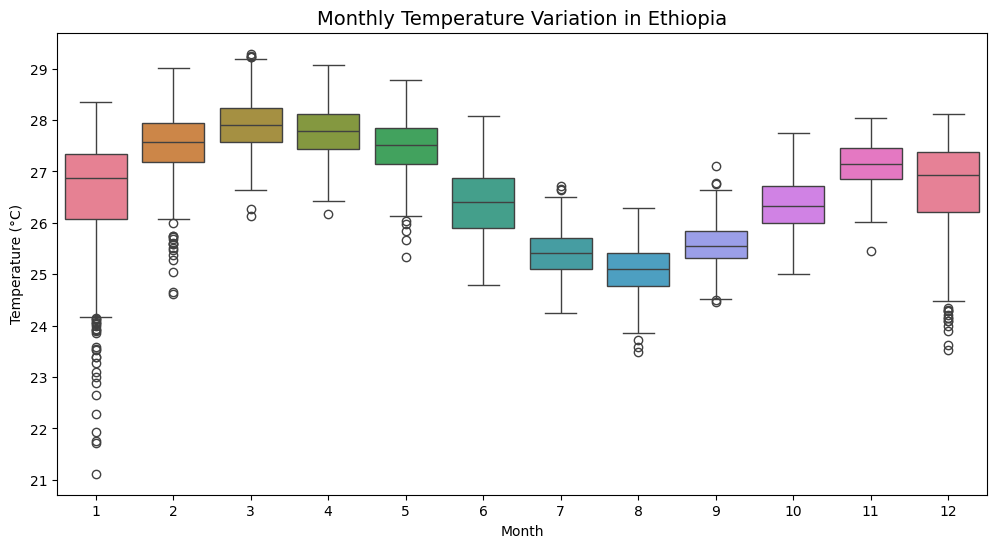

In [7]:
plt.figure(figsize=(12, 6))

# Using a 'cool' palette to reflect Ethiopia's highland climate
sns.boxplot(x='Month', y='T2M', data=df, hue='Month', palette='husl', legend=False)

plt.title('Monthly Temperature Variation in Ethiopia', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

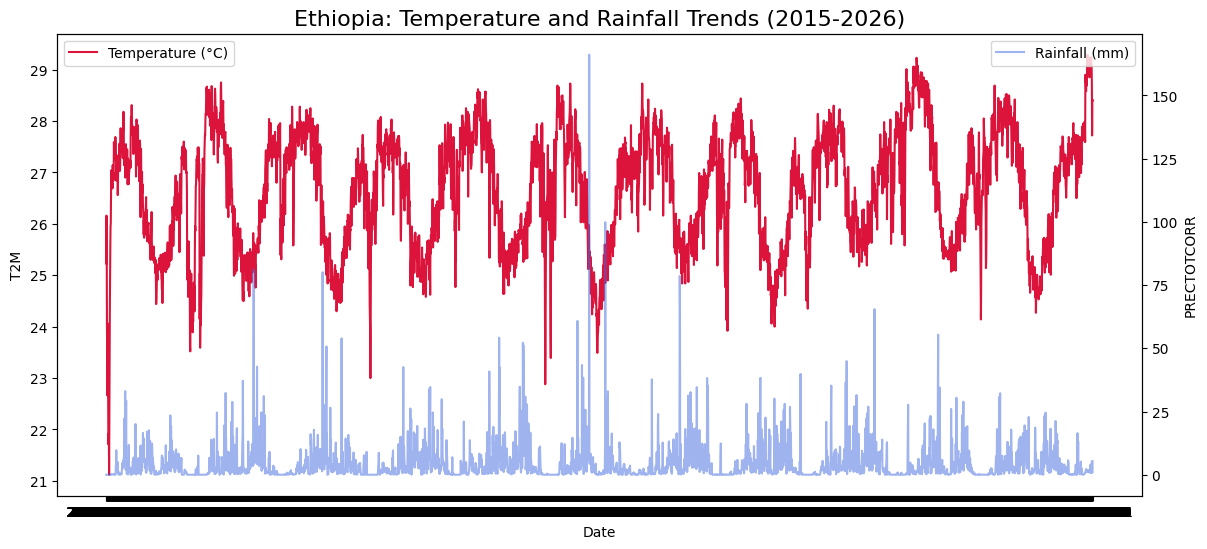

In [8]:
plt.figure(figsize=(14, 6))

# Plotting Temperature
sns.lineplot(x='Date', y='T2M', data=df, color='crimson', label='Temperature (°C)')

# Creating a second Y-axis for Rainfall
plt.twinx()
sns.lineplot(x='Date', y='PRECTOTCORR', data=df, color='royalblue', alpha=0.5, label='Rainfall (mm)')

plt.title('Ethiopia: Temperature and Rainfall Trends (2015-2026)', fontsize=16)
plt.xlabel('Year')
plt.show()

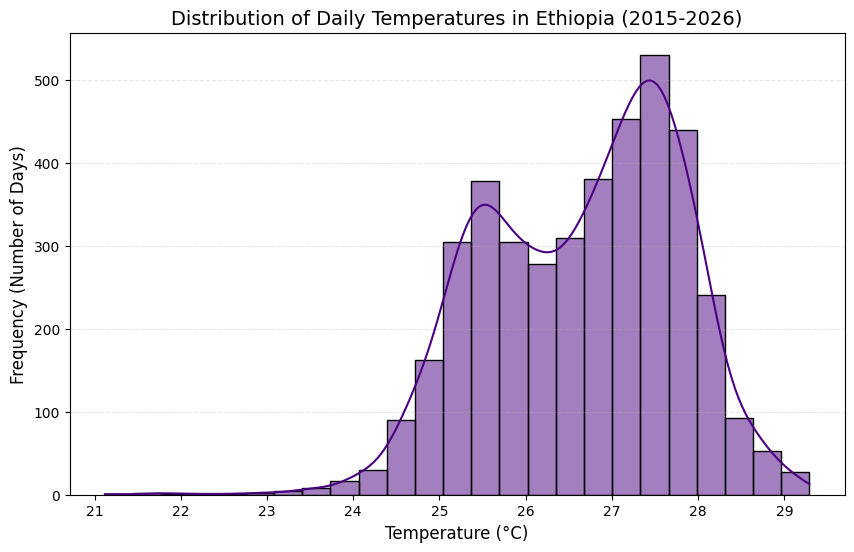

In [9]:
plt.figure(figsize=(10, 6))

# Using a deep purple or forest green to represent the Ethiopian highlands
sns.histplot(df['T2M'], bins=25, kde=True, color='#4B0082') 

plt.title('Distribution of Daily Temperatures in Ethiopia (2015-2026)', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Frequency (Number of Days)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()